# Advanced Visualization

# What Is Spatial Data?
Spatial data is data that includes information about where something is located. Unlike normal tables that only describe characteristics (like population or GDP), spatial data allows us to place information on a map and see geographic patterns.
- Spatial data = data + location
- Normal tables show what, not where
- Uses coordinates (latitude & longitude)
- Includes geometries (points for cities, boundaries for countries)
- Cities are mapped to compare population, economy, and environmental patterns visually

# Mapping with GeoPandas

        AGS       GEN   NUTS     Shape_Leng    Shape_Area  \
0  09563000     Fürth  DE253   49209.551437  6.334375e+07   
1  09162000   München  DE212  118084.194383  3.108342e+08   
2  09461000   Bamberg  DE241   44492.667416  5.464215e+07   
3  09262000    Passau  DE222   61360.769487  6.956591e+07   
4  09564000  Nürnberg  DE254  153997.952475  1.866370e+08   

   Pop_Benefit_Percent                                           geometry  
0            49.550707  MULTIPOLYGON (((4392577.758 2936451.016, 43926...  
1            70.270877  MULTIPOLYGON (((4432133.707 2774479.63, 443212...  
2            77.048748  MULTIPOLYGON (((4388203.406 2978639.586, 43882...  
3            78.069768  MULTIPOLYGON (((4570163.06 2838978.815, 457018...  
4            46.746620  MULTIPOLYGON (((4401927.814 2917518.273, 44019...  
Columns: ['AGS', 'GEN', 'NUTS', 'Shape_Leng', 'Shape_Area', 'Pop_Benefit_Percent', 'geometry']


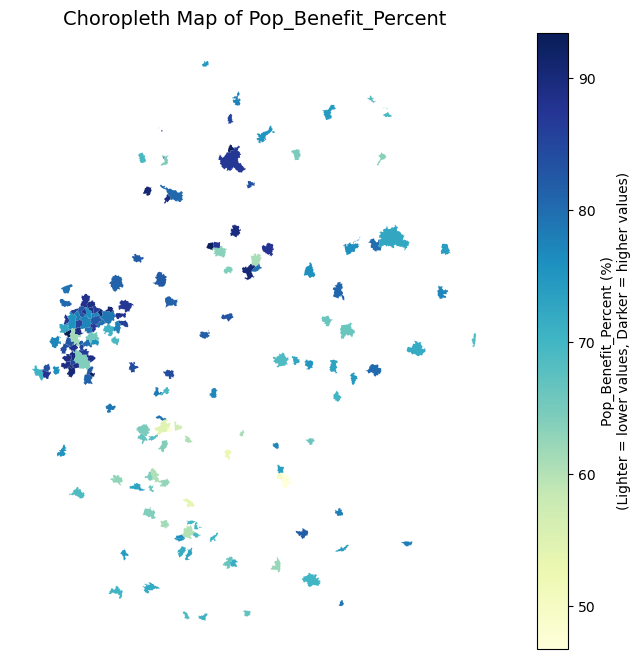

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1) Load a spatial dataset (replace with your file path)
gdf = gpd.read_file("../../00_data/downloaded_data/climate_regulation_in_cities.gpkg")

# 2) Quick check
print(gdf.head())
print("Columns:", list(gdf.columns))

# 3) Pick a numeric column to map
value_col = "Pop_Benefit_Percent"
if value_col not in gdf.columns:
    raise ValueError(f"Column '{value_col}' not found. Choose one from: {list(gdf.columns)}")

# 4) Plot a choropleth with clear color explanation
fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(
    column=value_col,
    ax=ax,
    cmap="YlGnBu",  # color scheme (yellow → green → blue)
    legend=True,
    legend_kwds={
        "label": f"{value_col} (%)\n(Lighter = lower values, Darker = higher values)",
        "orientation": "vertical"
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "Missing values"
    }
)

ax.set_title(f"Choropleth Map of {value_col}", fontsize=14)
ax.set_axis_off()

plt.show()

# How spatial joins work (conceptually)
A spatial join is like a normal table join, but instead of matching rows by an ID (like city_id), it matches rows by location.

- You have two layers: for example, cities (points) and regions (polygons).
- For each city point, GeoPandas checks which polygon it falls inside (or intersects, or is nearest to).
- Then it “attaches” the polygon’s attributes to the city row (or the other way around).

Example outcome: each city gets extra columns like region_name or district_id based on where it sits on the map.

We learned how to add city borders and names in the previous chapter. Let's do it again now! 

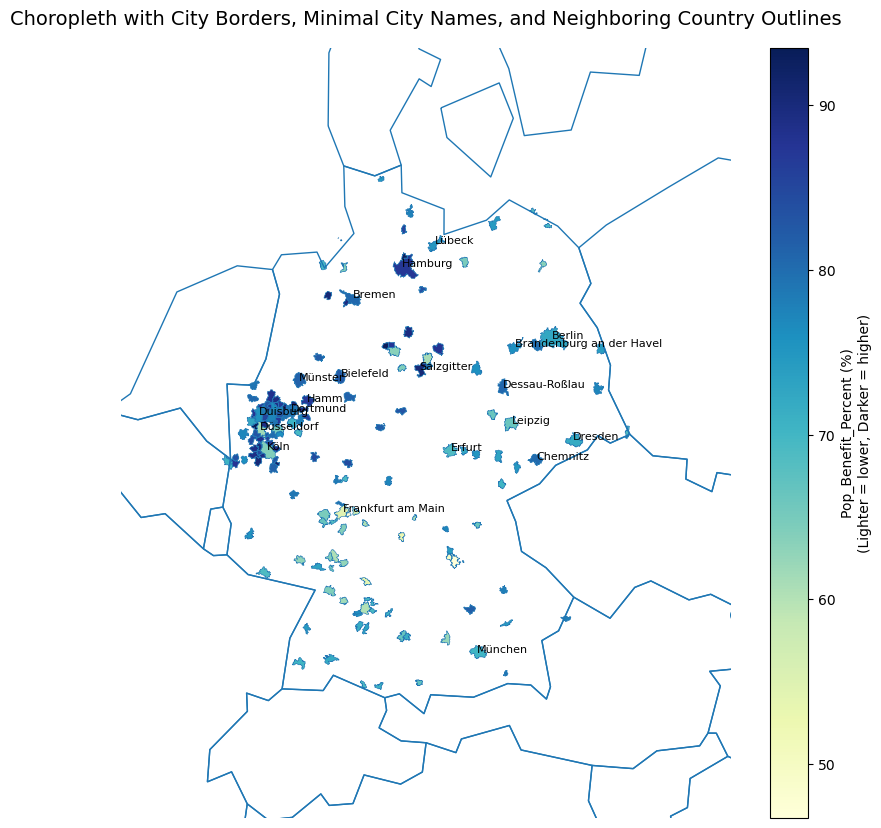

In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import numpy as np

# --- Inputs ---
value_col = "Pop_Benefit_Percent"
world_path = "../../00_data/downloaded_data/ne_110m_admin_0_countries.shp"

# 0) Pick a city name column (tries common options; falls back to first text column)
name_candidates = ["city", "City", "CITY", "name", "Name", "NAME", "city_name", "CityName", "GEN", "NAMES"]
name_col = next((c for c in name_candidates if c in gdf.columns), None)

if name_col is None:
    text_cols = [c for c in gdf.columns if gdf[c].dtype == "object" and c != gdf.geometry.name]
    if not text_cols:
        raise ValueError("No obvious city name column found. Add one (e.g., 'city' or 'name').")
    name_col = text_cols[0]

# 1) Load country borders (only for outlines/context)
world = gpd.read_file(world_path).to_crs(gdf.crs)

# 2) Build a bbox around your DATA extent (cities) + buffer so neighbors show up
minx, miny, maxx, maxy = gdf.total_bounds
dx, dy = (maxx - minx), (maxy - miny)
buffer_x, buffer_y = dx * 0.25, dy * 0.25

bbox_geom = box(minx - buffer_x, miny - buffer_y, maxx + buffer_x, maxy + buffer_y)
neighbors = world[world.intersects(bbox_geom)]

# 3) Choose a small subset of city labels (minimal names)
#    Strategy: label the largest cities by area (works well for polygons)
gdf_for_labels = gdf.copy()
gdf_for_labels["__area__"] = gdf_for_labels.geometry.area

N_LABELS = 20  # adjust for more/fewer labels
label_gdf = gdf_for_labels.sort_values("__area__", ascending=False).head(N_LABELS)

# 4) Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Choropleth layer (main focus)
gdf.plot(
    column=value_col,
    cmap="YlGnBu",
    legend=True,
    legend_kwds={"label": f"{value_col} (%)\n(Lighter = lower, Darker = higher)"},
    edgecolor="none",
    ax=ax
)

# City borders
gdf.boundary.plot(ax=ax, linewidth=0.4)

# Neighboring country borders (outlines only)
neighbors.boundary.plot(ax=ax, linewidth=1.0)

# Add minimal city names at centroids
# (for polygons, use representative_point() so labels stay inside shapes)
label_points = label_gdf.representative_point()
for x, y, name in zip(label_points.x, label_points.y, label_gdf[name_col].astype(str)):
    ax.text(x, y, name, fontsize=8)

# Zoom to data extent
ax.set_xlim(minx - buffer_x, maxx + buffer_x)
ax.set_ylim(miny - buffer_y, maxy + buffer_y)

ax.set_title("Choropleth with City Borders, Minimal City Names, and Neighboring Country Outlines", fontsize=14)
ax.set_axis_off()

plt.show()

# Advanced visualizations (scientific-style) for polygon city data
Binned choropleth (quantiles / equal intervals)

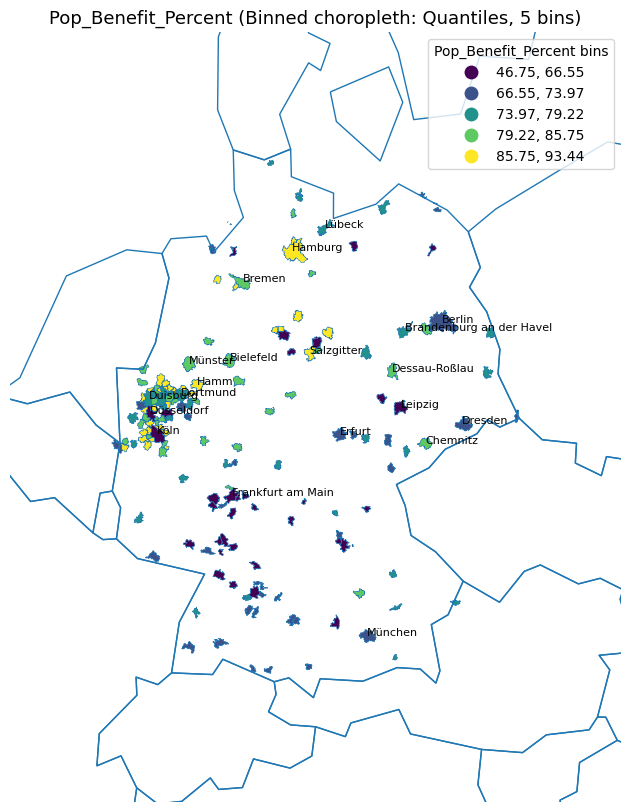

In [9]:
# Advanced map cell (self-contained):
# - binned choropleth (Quantiles)
# - city borders
# - minimal city names from GEN
# - neighboring country outlines
# - zoom focused on your city data

import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import mapclassify  # pip install mapclassify
import numpy as np

# --- Inputs ---
value_col = "Pop_Benefit_Percent"   # numeric column to map
name_col  = "GEN"                   # city-name column
world_path = "../../00_data/downloaded_data/ne_110m_admin_0_countries.shp"

N_BINS = 5
N_LABELS = 20
BUFFER_FRAC = 0.25

# --- Safety checks ---
if value_col not in gdf.columns:
    raise ValueError(f"'{value_col}' not found. Available: {list(gdf.columns)}")
if name_col not in gdf.columns:
    raise ValueError(f"'{name_col}' not found. Available: {list(gdf.columns)}")

# Ensure numeric
gdf2 = gdf.copy()
gdf2[value_col] = gdf2[value_col].astype(float)

# --- Load neighboring country outlines (context only) ---
world = gpd.read_file(world_path).to_crs(gdf2.crs)

# --- Compute bbox from city data extent (keeps focus on your dataset) ---
minx, miny, maxx, maxy = gdf2.total_bounds
dx, dy = (maxx - minx), (maxy - miny)
buffer_x, buffer_y = dx * BUFFER_FRAC, dy * BUFFER_FRAC
bbox_geom = box(minx - buffer_x, miny - buffer_y, maxx + buffer_x, maxy + buffer_y)

neighbors = world[world.intersects(bbox_geom)]

# --- Minimal city labels: pick the largest polygons (cleaner, less clutter) ---
labels_gdf = gdf2.copy()
labels_gdf["_area"] = labels_gdf.geometry.area
labels_gdf = labels_gdf.sort_values("_area", ascending=False).head(N_LABELS)
label_pts = labels_gdf.representative_point()  # works well for MultiPolygons

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))

# 1) Neighbor country outlines (behind)
neighbors.boundary.plot(ax=ax, linewidth=1.0)

# 2) Binned choropleth (Quantiles)
gdf2.plot(
    column=value_col,
    scheme="Quantiles",   # try: "EqualInterval" or "FisherJenks"
    k=N_BINS,
    legend=True,
    edgecolor="none",
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)

# 3) City borders (on top for readability)
gdf2.boundary.plot(ax=ax, linewidth=0.4)

# 4) Minimal city names using GEN
for x, y, nm in zip(label_pts.x, label_pts.y, labels_gdf[name_col].astype(str)):
    ax.text(x, y, nm, fontsize=8)

# 5) Zoom to your data (+ buffer)
ax.set_xlim(minx - buffer_x, maxx + buffer_x)
ax.set_ylim(miny - buffer_y, maxy + buffer_y)

ax.set_title(f"{value_col} (Binned choropleth: Quantiles, {N_BINS} bins)", fontsize=13)
ax.set_axis_off()

# Version-safe legend title
leg = ax.get_legend()
if leg:
    leg.set_title(f"{value_col} bins")

plt.show()

A binned choropleth groups numeric values into categories instead of showing a smooth color gradient. These categories are called bins. When we use quantiles, each bin contains roughly the same number of cities, which makes comparisons balanced and easier to interpret. The numbers in the legend show the value range for each bin (for example, 10–20 means cities in that range share the same color). From a color theory perspective, grouping values into distinct color steps improves readability and reduces visual noise, helping patterns stand out more clearly than a continuous gradient.